# 02. 탐색적 데이터 분석 (Exploratory Data Analysis)

## 프로젝트: 반도체 수율 예측 (Semiconductor Yield Prediction)

### 분석 목적

본 Notebook에서는 SECOM 반도체 제조 데이터를 탐색적으로 분석하여,
수율 및 불량 예측과 관련된 주요 데이터 특성과 패턴을 파악한다.

### 주요 분석 질문

1. Pass와 Fail 간 클래스 불균형은 어느 정도인가?
2. 센서 변수의 결측값은 어떤 형태로 분포되어 있는가?
3. 예측에 유용한 정보를 제공하지 않는 센서 변수가 존재하는가?
4. 주요 센서 변수의 값은 어떤 분포를 보이는가?
5. 센서 변수와 Fail 여부 사이에는 어떠한 통계적 관계가 존재하는가?
6. 이러한 데이터 특성을 바탕으로 어떤 전처리 및 모델링 전략이 필요한가?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

In [2]:
DATA_PATH = Path("../data/processed/uci-secom.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1567, 592)


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,feature_31,feature_32,feature_33,feature_34,feature_35,feature_36,feature_37,feature_38,feature_39,feature_40,feature_41,feature_42,feature_43,feature_44,feature_45,feature_46,feature_47,feature_48,feature_49,...,feature_542,feature_543,feature_544,feature_545,feature_546,feature_547,feature_548,feature_549,feature_550,feature_551,feature_552,feature_553,feature_554,feature_555,feature_556,feature_557,feature_558,feature_559,feature_560,feature_561,feature_562,feature_563,feature_564,feature_565,feature_566,feature_567,feature_568,feature_569,feature_570,feature_571,feature_572,feature_573,feature_574,feature_575,feature_576,feature_577,feature_578,feature_579,feature_580,feature_581,feature_582,feature_583,feature_584,feature_585,feature_586,feature_587,feature_588,feature_589,Time,Pass/Fail
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,-0.0034,0.9455,202.4396,0.0,7.9558,414.8710,10.0433,0.9680,192.3963,12.5190,1.4026,-5419.00,2916.50,-4043.75,751.00,0.8955,1.7730,3.0490,64.2333,2.0222,0.1632,3.5191,83.3971,9.5126,50.6170,64.2588,49.3830,66.3141,86.9555,117.5132,61.29,4.515,70.0,352.7173,10.1841,130.3691,723.3092,1.3072,141.2282,1.0,...,0.1096,0.0078,0.0026,7.116,1.0616,395.570,75.752,0.4234,12.93,0.78,0.1827,5.7349,0.3363,39.8842,3.2687,1.0297,1.0344,0.4385,0.1039,42.3877,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,533.8500,2.1113,8.95,0.3157,3.0624,0.1026,1.6765,14.9509,NaN,NaN,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,2008-07-19 11:55:00,-1
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,-0.0148,0.9627,200.5470,0.0,10.1548,414.7347,9.2599,0.9701,191.2872,12.4608,1.3825,-5441.50,2604.25,-3498.75,-1640.25,1.2973,2.0143,7.3900,68.4222,2.2667,0.2102,3.4171,84.9052,9.7997,50.6596,64.2828,49.3404,64.9193,87.5241,118.1188,78.25,2.773,70.0,352.2445,10.0373,133.1727,724.8264,1.2887,145.8445,1.0,...,0.1096,0.0078,0.0026,7.116,1.3526,408.798,74.640,0.7193,16.00,1.33,0.2829,7.1196,0.4989,53.1836,3.9139,1.7819,0.9634,0.1745,0.0375,18.1087,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,535.0164,2.4335,5.92,0.2653,2.0111,0.0772,1.1065,10.9003,0.0096,0.0201,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,2008-07-19 12:32:00,-1
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,0.0013,0.9615,202.0179,0.0,9.5157,416.7075,9.3144,0.9674,192.7035,12.5404,1.4123,-5447.75,2701.75,-4047.00,-1916.50,1.3122,2.0295,7.5788,67.1333,2.3333,0.1734,3.5986,84.7569,8.6590,50.1530,64.1114,49.8470,65.8389,84.7327,118.6128,14.37,5.434,70.0,364.3782,9.8783,131.8027,734.7924,1.2992,141.0845,1.0,...,0.1096,0.0078,0.0026,7.116,0.7942,411.136,74.654,0.1832,16.16,0.85,0.0857,7.1619,0.3752,23.0713,3.9306,1.1386,1.5021,0.3718,0.1233,24.7524,267.064,0.9032,1.10,0.6219,0.4122,0.2562,0.4119,68.8489,535.0245,2.0293,11.21,0.1882,4.0923,0.0640,2.0952,9.2721,0.0584,0.0484,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,2008-07-19 13:17:00,1
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,-0.0033,0.9629,201.8482,0.0,9.6052,422.2894,9.6924,0.9687,192.1557,12.4782,1.4011,-5468.25,2648.25,-4515.00,-1657.25,1.3137,2.0038,7.3145,62.9333,2.6444,0.2071,3.3813,84.9105,8.6789,50.5100,64.1125,49.4900,65.1951,86.6867,117.0442,76.90,1.279,70.0,363.0273,9.9305,131.8027,733.8778,1.3027,142.5427,1.0,...,0.1096,0.0078,0.0026,7.116,1.1650,372.822,72.442,1.8804,131.68,39.33,0.6812,56.9303,17.4781,161.4081,35.3198,54.2917,1.1613,0.7288,0.2710,62.7572,268.228,0.6511,7.32,0.1630,3.5611,0.0670,2.7290,25.0363,530.5682,2.0253,9.33,0.1738,2.8971,0.0525,1.7585,8.5831,0.0202,0.0149,0.0044,73.8432,0.4990,0.0103,0.002

In [3]:
df["Time"] = pd.to_datetime(df["Time"])

print(df["Time"].dtype)

datetime64[us]


In [4]:
feature_cols = [
    col for col in df.columns
    if col.startswith("feature_")
]

print("Number of sensor features:", len(feature_cols))

Number of sensor features: 590


## 1. Pass/Fail 클래스 분포 분석 (Class Distribution)

SECOM 데이터는 Pass 샘플에 비해 Fail 샘플의 수가 매우 적은
심각한 클래스 불균형(Class Imbalance)을 가지고 있다.

불량 샘플이 전체 데이터에서 차지하는 비율이 매우 낮기 때문에,
단순히 Accuracy만으로 모델의 성능을 평가하면 실제 불량 검출 능력을
제대로 판단하기 어렵다.

따라서 먼저 Pass와 Fail의 샘플 수 및 비율을 확인하여
클래스 불균형의 정도를 파악한다.

In [5]:
class_counts = (
    df["Pass/Fail"]
    .value_counts()
    .sort_index()
)

class_counts

Pass/Fail
-1    1463
 1     104
Name: count, dtype: int64

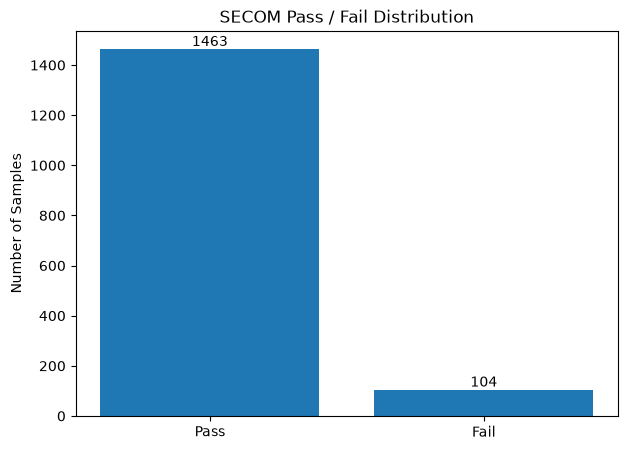

In [6]:
class_labels = ["Pass", "Fail"]
class_values = [
    (df["Pass/Fail"] == -1).sum(),
    (df["Pass/Fail"] == 1).sum()
]

plt.figure(figsize=(7, 5))

bars = plt.bar(
    class_labels,
    class_values
)

plt.title("SECOM Pass / Fail Distribution")
plt.ylabel("Number of Samples")

for bar, value in zip(bars, class_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        str(value),
        ha="center",
        va="bottom"
    )

plt.show()

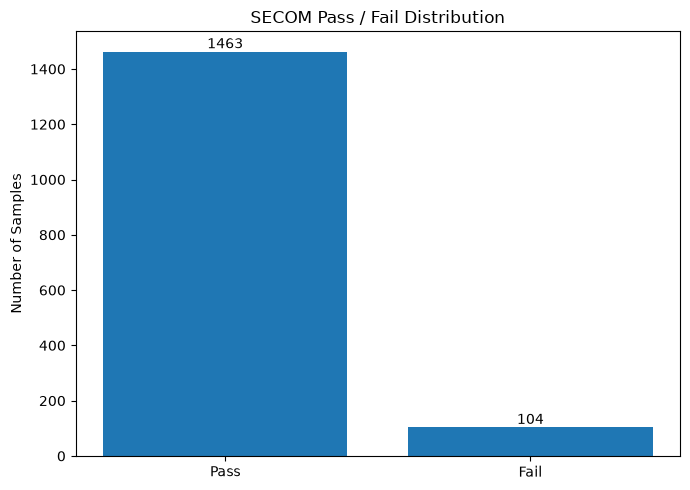

Saved to: ..\results\figures\class_distribution.png


In [7]:
FIGURE_PATH = Path(
    "../results/figures/class_distribution.png"
)

plt.figure(figsize=(7, 5))

bars = plt.bar(
    class_labels,
    class_values
)

plt.title("SECOM Pass / Fail Distribution")
plt.ylabel("Number of Samples")

for bar, value in zip(bars, class_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        str(value),
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved to:", FIGURE_PATH)

In [8]:
pass_ratio = (
    (df["Pass/Fail"] == -1).mean() * 100
)

fail_ratio = (
    (df["Pass/Fail"] == 1).mean() * 100
)

print(f"Pass ratio : {pass_ratio:.2f}%")
print(f"Fail ratio : {fail_ratio:.2f}%")

Pass ratio : 93.36%
Fail ratio : 6.64%


### 분석 결과 (Observation)

- Pass 샘플은 전체 데이터의 약 **93.36%**를 차지한다.
- Fail 샘플은 전체 데이터의 약 **6.64%**에 불과하다.
- 따라서 모든 샘플을 단순히 Pass라고 예측하는 모델도 약 93% 이상의 Accuracy를 얻을 수 있다.
- 그러나 이러한 모델은 실제 Fail 샘플을 단 하나도 검출하지 못하므로 반도체 불량 예측 모델로서 의미가 없다.

### 모델링 관점의 시사점 (Modeling Implication)

본 데이터에서는 Accuracy를 모델의 주요 성능 지표로 사용하는 것이 적절하지 않다.

이후 모델링 단계에서는 실제 Fail 샘플을 얼마나 잘 검출하는지를 중심으로 다음 평가 지표를 함께 확인한다.

- Fail 클래스의 Recall
- Precision
- F1-score / F2-score
- PR-AUC
- Confusion Matrix

특히 실제 불량을 정상으로 잘못 판단하는 False Negative를 줄이는 것이
반도체 불량 검출 관점에서 중요한 평가 요소가 된다.

## 2. 결측치 분석 (Missing Value Analysis)

SECOM 데이터에는 다수의 센서 측정값이 결측치(Missing Value)로 존재한다.

센서 변수별 결측률을 분석하여 결측값이 전체 변수에 고르게 분포하는지,
또는 일부 센서 변수에 집중되어 있는지를 확인한다.

특히 결측률이 지나치게 높은 변수는 실제로 사용할 수 있는 정보가
매우 제한적일 수 있으므로 이후 전처리 과정에서 제거 후보로 고려할 수 있다.

단, 본 EDA 단계에서는 데이터의 특성을 파악하는 것에 목적을 두며,
실제 변수 제거 및 결측값 대체(Imputation)는 이후 전처리 단계에서 수행한다.

In [9]:
missing_ratio = (
    df[feature_cols]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_ratio.head(20)

feature_292    91.193363
feature_293    91.193363
feature_158    91.193363
feature_157    91.193363
feature_492    85.577537
feature_85     85.577537
feature_358    85.577537
feature_220    85.577537
feature_244    64.964901
feature_517    64.964901
feature_109    64.964901
feature_246    64.964901
feature_383    64.964901
feature_382    64.964901
feature_384    64.964901
feature_245    64.964901
feature_111    64.964901
feature_110    64.964901
feature_516    64.964901
feature_518    64.964901
dtype: float64

In [10]:
print(
    "Features with missing values:",
    (missing_ratio > 0).sum()
)

print(
    "Features with >= 10% missing:",
    (missing_ratio >= 10).sum()
)

print(
    "Features with >= 20% missing:",
    (missing_ratio >= 20).sum()
)

print(
    "Features with >= 40% missing:",
    (missing_ratio >= 40).sum()
)

print(
    "Maximum missing ratio:",
    f"{missing_ratio.max():.2f}%"
)

Features with missing values: 538
Features with >= 10% missing: 52
Features with >= 20% missing: 32
Features with >= 40% missing: 32
Maximum missing ratio: 91.19%


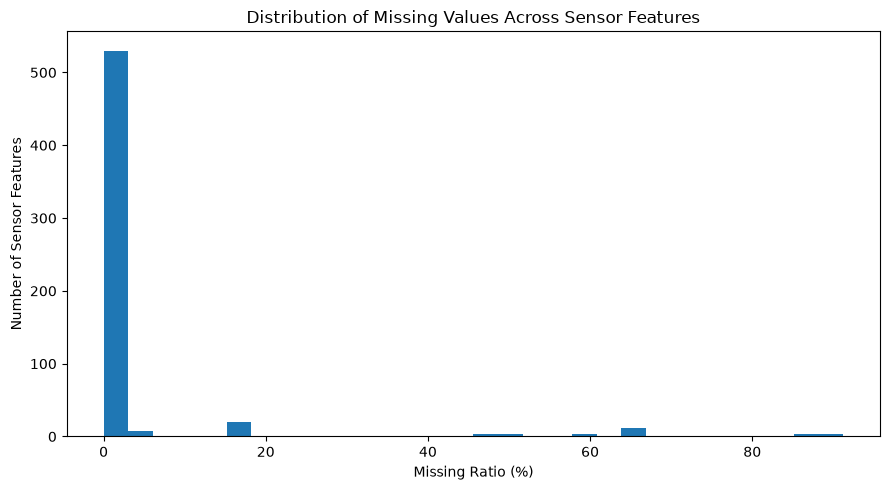

In [11]:
plt.figure(figsize=(9, 5))

plt.hist(
    missing_ratio,
    bins=30
)

plt.xlabel("Missing Ratio (%)")
plt.ylabel("Number of Sensor Features")
plt.title("Distribution of Missing Values Across Sensor Features")

plt.tight_layout()
plt.show()

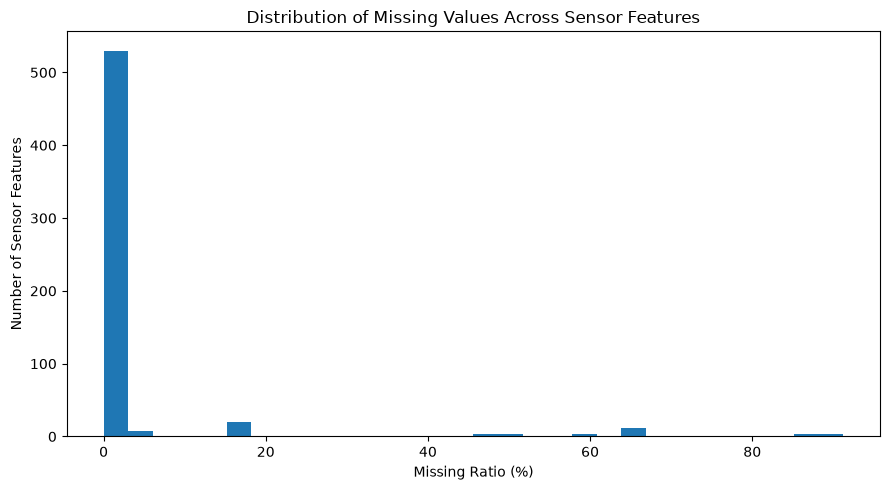

In [12]:
MISSING_FIGURE_PATH = Path(
    "../results/figures/missing_ratio_distribution.png"
)

plt.figure(figsize=(9, 5))

plt.hist(
    missing_ratio,
    bins=30
)

plt.xlabel("Missing Ratio (%)")
plt.ylabel("Number of Sensor Features")
plt.title("Distribution of Missing Values Across Sensor Features")

plt.tight_layout()

plt.savefig(
    MISSING_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 3. 정보량이 없는 센서 변수 분석 (Non-Informative Sensor Features)

일부 센서 변수는 불량 예측에 활용할 수 있는 유의미한 정보를 제공하지 않을 수 있다.

본 단계에서는 다음 두 유형의 변수를 확인한다.

- 모든 관측값이 결측치인 변수
- 결측치를 제외했을 때 하나의 값만 가지는 변수

이러한 변수들은 샘플 간 차이를 구분할 수 없으므로,
이후 전처리 단계에서 제거 후보로 고려한다.

단, 본 EDA 단계에서는 데이터의 특성을 파악하는 것에 목적을 두며
실제 변수 제거는 이후 전처리 과정에서 수행한다.

In [13]:
all_missing_features = [
    col for col in feature_cols
    if df[col].isna().all()
]

single_value_features = [
    col for col in feature_cols
    if df[col].nunique(dropna=True) == 1
]

print("All-missing features :", len(all_missing_features))
print("Single-value features:", len(single_value_features))

All-missing features : 0
Single-value features: 116


In [14]:
print("All-missing features:")
print(all_missing_features)

print("\nSingle-value features:")
print(single_value_features)

All-missing features:
[]

Single-value features:
['feature_5', 'feature_13', 'feature_42', 'feature_49', 'feature_52', 'feature_69', 'feature_97', 'feature_141', 'feature_149', 'feature_178', 'feature_179', 'feature_186', 'feature_189', 'feature_190', 'feature_191', 'feature_192', 'feature_193', 'feature_194', 'feature_226', 'feature_229', 'feature_230', 'feature_231', 'feature_232', 'feature_233', 'feature_234', 'feature_235', 'feature_236', 'feature_237', 'feature_240', 'feature_241', 'feature_242', 'feature_243', 'feature_256', 'feature_257', 'feature_258', 'feature_259', 'feature_260', 'feature_261', 'feature_262', 'feature_263', 'feature_264', 'feature_265', 'feature_266', 'feature_276', 'feature_284', 'feature_313', 'feature_314', 'feature_315', 'feature_322', 'feature_325', 'feature_326', 'feature_327', 'feature_328', 'feature_329', 'feature_330', 'feature_364', 'feature_369', 'feature_370', 'feature_371', 'feature_372', 'feature_373', 'feature_374', 'feature_375', 'feature_378'

In [15]:
non_informative_features = list(
    set(all_missing_features + single_value_features)
)

informative_features = [
    col for col in feature_cols
    if col not in non_informative_features
]

print("Original sensor features    :", len(feature_cols))
print("Non-informative features    :", len(non_informative_features))
print("Remaining candidate features:", len(informative_features))

Original sensor features    : 590
Non-informative features    : 116
Remaining candidate features: 474


## 4. 센서 변수 기초 통계 분석 (Sensor Feature Statistics)

SECOM 데이터의 각 센서 변수에 대해 평균, 표준편차, 최솟값,
최댓값 및 사분위수 등의 기초 통계량을 확인한다.

이를 통해 센서 변수별 값의 범위와 분산 정도를 파악할 수 있다.

SECOM의 센서 변수는 익명화되어 있으며 각 변수의 측정 단위 또한
동일하다고 볼 수 없으므로, 서로 다른 센서 변수의 원시 분산값을
단순 비교하여 중요도를 판단하지 않는다.

In [16]:
feature_statistics = df[informative_features].describe().T

feature_statistics.head(20)

,count,mean,std,min,25%,50%,75%,max
feature_0,1561.0,3014.452896,73.621787,2743.2400,2966.260000,3011.49000,3056.650000,3356.3500
feature_1,1560.0,2495.850231,80.407705,2158.7500,2452.247500,2499.40500,2538.822500,2846.4400
feature_2,1553.0,2200.547318,29.513152,2060.6600,2181.044400,2201.06670,2218.055500,2315.2667
feature_3,1553.0,1396.376627,441.691640,0.0000,1081.875800,1285.21440,1591.223500,3715.0417
feature_4,1553.0,4.197013,56.355540,0.6815,1.017700,1.31680,1.525700,1114.5366
feature_6,1553.0,101.112908,6.237214,82.1311,97.920000,101.51220,104.586700,129.2522
feature_7,1558.0,0.121822,0.008961,0.0000,0.121100,0.12240,0.123800,0.1286
feature_8,1565.0,1.462862,0.073897,1.1910,1.411200,1.46160,1.516900,1.6564
feature_9,1565.0,-0.000841,0.015116,-0.0534,-0.010800,-0.00130,0.008400,0.0749
feature_10,1565.0,0.000146,0.009302,-0.0349,-0.005600,0.00040,0.005900,0.0530


In [17]:
df["Fail"] = (df["Pass/Fail"] == 1).astype(int)

df[["Pass/Fail", "Fail"]].head()

C:\Users\ark34\AppData\Local\Temp\ipykernel_17932\2283704967.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Fail"] = (df["Pass/Fail"] == 1).astype(int)


,Pass/Fail,Fail
0,-1,0
1,-1,0
2,1,1
3,-1,0
4,-1,0


In [18]:
feature_fail_corr = (
    df[informative_features]
    .corrwith(df["Fail"])
    .dropna()
)

feature_fail_corr_abs = (
    feature_fail_corr
    .abs()
    .sort_values(ascending=False)
)

feature_fail_corr_abs.head(20)

feature_59     0.155796
feature_103    0.151203
feature_510    0.131593
feature_348    0.130180
feature_158    0.121258
feature_431    0.120851
feature_293    0.114494
feature_111    0.113950
feature_434    0.112116
feature_430    0.110067
feature_435    0.109067
feature_21     0.108488
feature_28     0.107252
feature_436    0.106910
feature_85     0.103559
feature_129    0.103373
feature_210    0.102545
feature_298    0.102519
feature_163    0.100330
feature_124    0.093994
dtype: float64

In [19]:
top_corr_features = feature_fail_corr_abs.head(10)

top_corr_df = pd.DataFrame({
    "Feature": top_corr_features.index,
    "Absolute correlation with Fail": top_corr_features.values
})

top_corr_df

,Feature,Absolute correlation with Fail
0,feature_59,0.155796
1,feature_103,0.151203
2,feature_510,0.131593
3,feature_348,0.130180
4,feature_158,0.121258
5,feature_431,0.120851
6,feature_293,0.114494
7,feature_111,0.113950
8,feature_434,0.112116
9,feature_430,0.110067


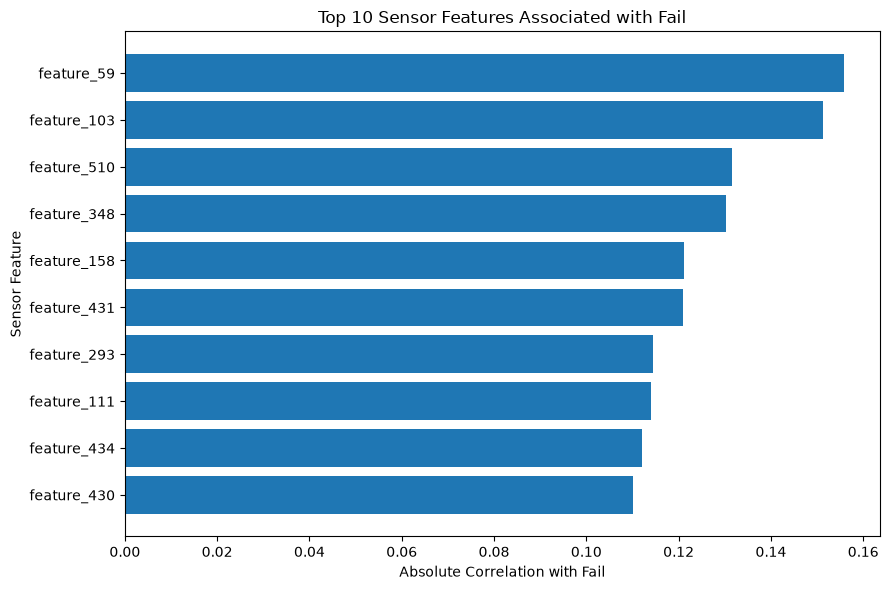

In [20]:
plt.figure(figsize=(9, 6))

plt.barh(
    top_corr_df["Feature"][::-1],
    top_corr_df["Absolute correlation with Fail"][::-1]
)

plt.xlabel("Absolute Correlation with Fail")
plt.ylabel("Sensor Feature")
plt.title("Top 10 Sensor Features Associated with Fail")

plt.tight_layout()

plt.show()

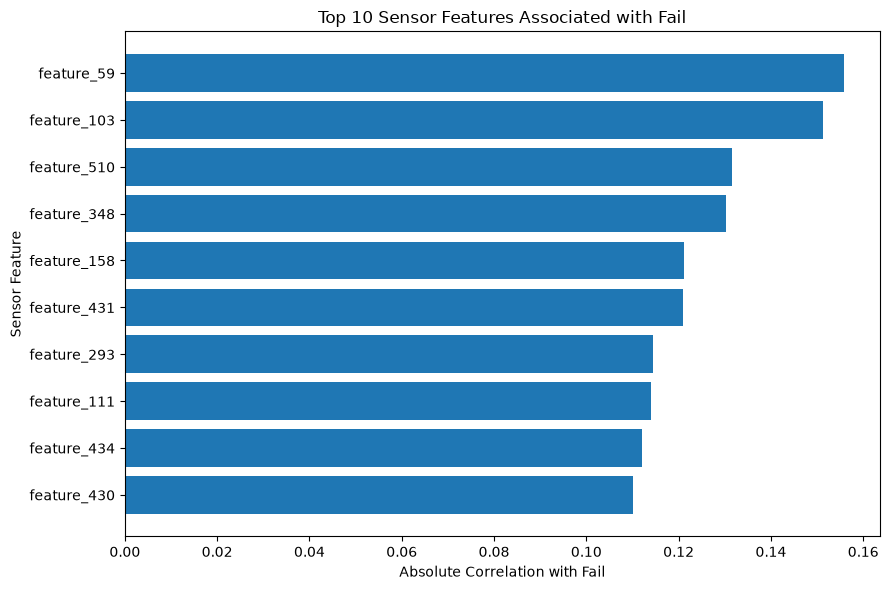

In [21]:
CORR_FIGURE_PATH = Path(
    "../results/figures/top_fail_correlations.png"
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_corr_df["Feature"][::-1],
    top_corr_df["Absolute correlation with Fail"][::-1]
)

plt.xlabel("Absolute Correlation with Fail")
plt.ylabel("Sensor Feature")
plt.title("Top 10 Sensor Features Associated with Fail")

plt.tight_layout()

plt.savefig(
    CORR_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 해석 시 주의사항

위 상관관계 분석 결과는 각 센서 변수와 Fail 여부 사이의
통계적 연관성을 탐색적으로 확인한 결과이다.

따라서 상관계수가 상대적으로 높게 나타난 센서 변수를
반도체 불량의 직접적인 원인(Root Cause)이라고 해석해서는 안 된다.

SECOM 데이터의 센서 변수는 익명화되어 있어 각 변수가 실제 공정의
어떤 물리적 파라미터를 의미하는지 확인할 수 없으며,
상관관계 자체도 인과관계를 의미하지 않는다.

또한 본 EDA에서는 전체 데이터를 활용하여 관계를 탐색하였으므로,
여기서 확인한 결과를 모델 학습 과정의 Feature Selection에
직접 사용하지 않는다.

실제 Feature Selection은 데이터 누수(Data Leakage)를 방지하기 위해
이후 모델링 단계에서 Training Data만을 이용하여 수행한다.

### 주요 센서 변수의 Pass/Fail 분포 비교

Fail 여부와 상대적으로 높은 상관관계를 보인 센서 변수들을 대상으로
Pass 샘플과 Fail 샘플의 값 분포를 비교한다.

SECOM 데이터는 Pass 샘플이 Fail 샘플보다 압도적으로 많기 때문에,
단순 빈도(Count)를 이용하면 두 집단의 분포 형태를 비교하기 어렵다.

따라서 각 집단의 분포를 정규화한 Density를 이용하여
Pass와 Fail 간 센서 값 분포의 차이를 탐색적으로 확인한다.

In [22]:
selected_features = (
    top_corr_df["Feature"]
    .head(3)
    .tolist()
)

print("Selected features:")
print(selected_features)

Selected features:
['feature_59', 'feature_103', 'feature_510']


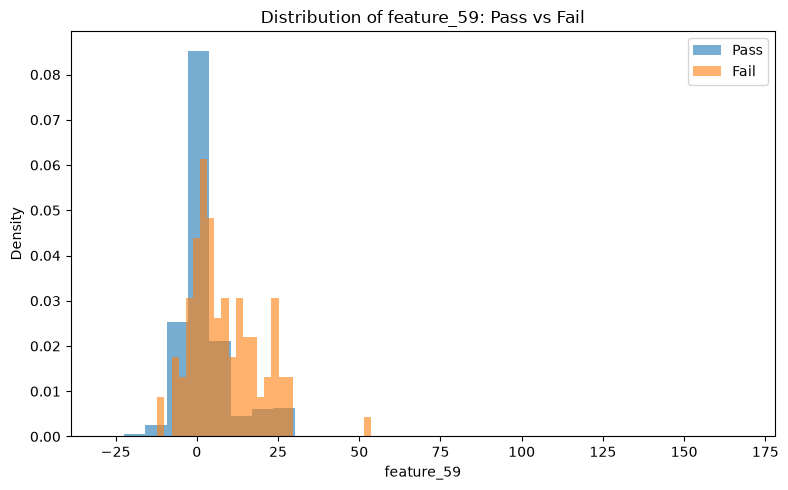

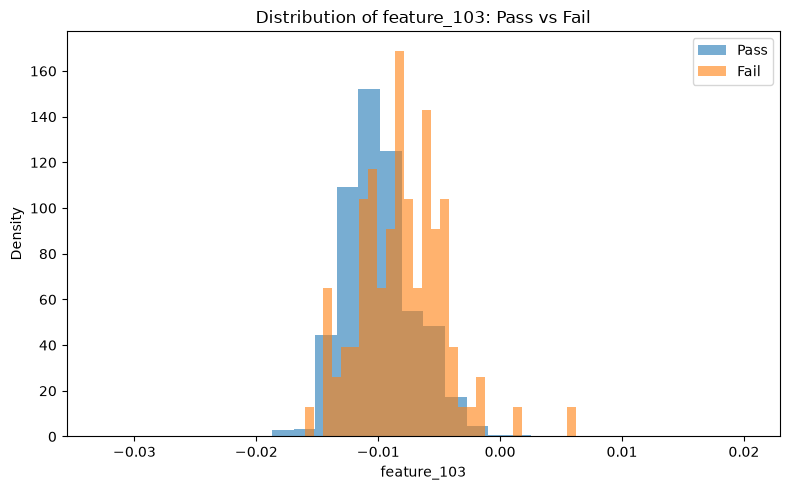

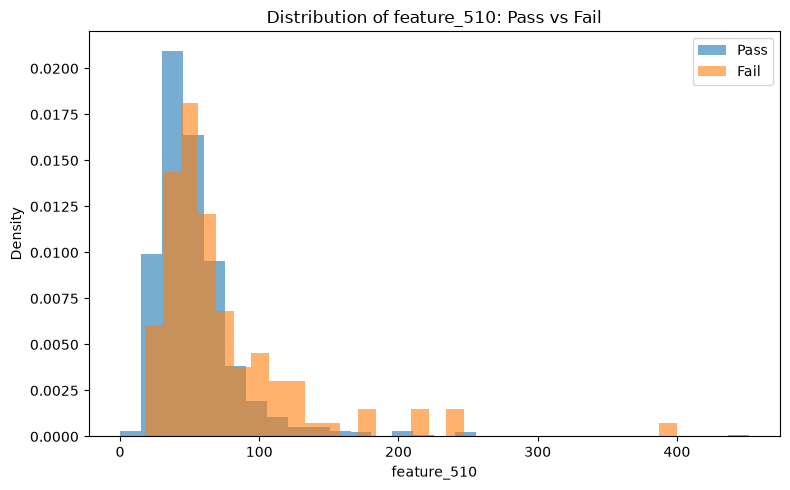

In [23]:
for feature in selected_features:

    pass_values = df.loc[
        df["Pass/Fail"] == -1,
        feature
    ].dropna()

    fail_values = df.loc[
        df["Pass/Fail"] == 1,
        feature
    ].dropna()

    plt.figure(figsize=(8, 5))

    plt.hist(
        pass_values,
        bins=30,
        density=True,
        alpha=0.6,
        label="Pass"
    )

    plt.hist(
        fail_values,
        bins=30,
        density=True,
        alpha=0.6,
        label="Fail"
    )

    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.title(
        f"Distribution of {feature}: Pass vs Fail"
    )

    plt.legend()
    plt.tight_layout()

    plt.show()

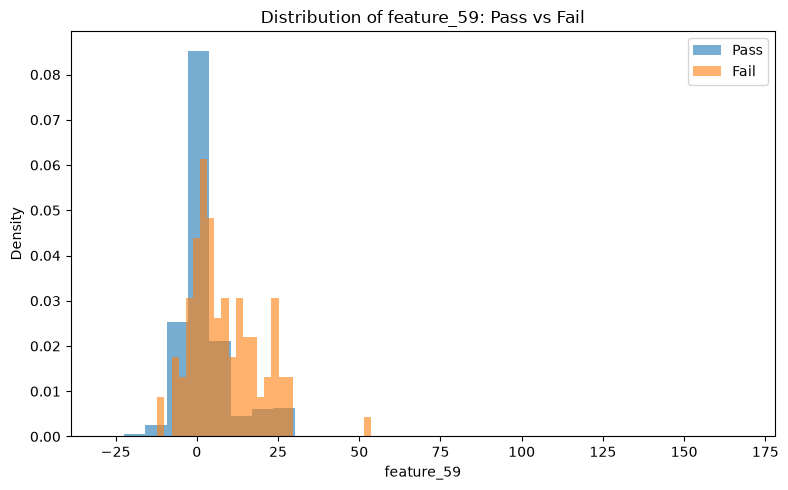

Saved to: ..\results\figures\feature_59_pass_fail_distribution.png


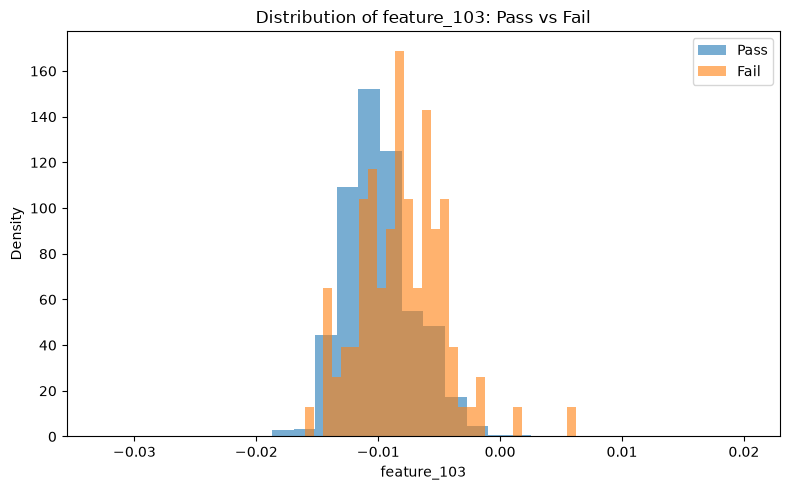

Saved to: ..\results\figures\feature_103_pass_fail_distribution.png


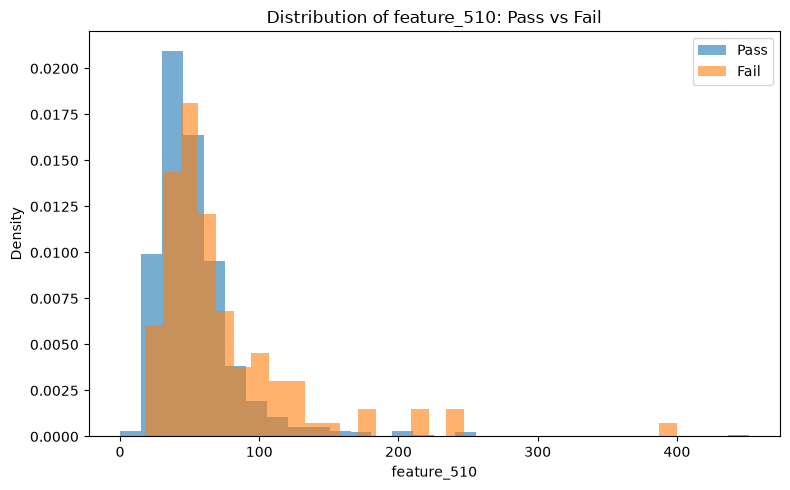

Saved to: ..\results\figures\feature_510_pass_fail_distribution.png


In [24]:
for feature in selected_features:

    pass_values = df.loc[
        df["Pass/Fail"] == -1,
        feature
    ].dropna()

    fail_values = df.loc[
        df["Pass/Fail"] == 1,
        feature
    ].dropna()

    plt.figure(figsize=(8, 5))

    plt.hist(
        pass_values,
        bins=30,
        density=True,
        alpha=0.6,
        label="Pass"
    )

    plt.hist(
        fail_values,
        bins=30,
        density=True,
        alpha=0.6,
        label="Fail"
    )

    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.title(
        f"Distribution of {feature}: Pass vs Fail"
    )

    plt.legend()
    plt.tight_layout()

    output_path = Path(
        f"../results/figures/{feature}_pass_fail_distribution.png"
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("Saved to:", output_path)

In [25]:
distribution_summary = []

for feature in selected_features:

    pass_values = df.loc[
        df["Pass/Fail"] == -1,
        feature
    ]

    fail_values = df.loc[
        df["Pass/Fail"] == 1,
        feature
    ]

    distribution_summary.append({
        "Feature": feature,

        "Pass Mean":
            pass_values.mean(),

        "Fail Mean":
            fail_values.mean(),

        "Pass Median":
            pass_values.median(),

        "Fail Median":
            fail_values.median()
    })

distribution_summary_df = pd.DataFrame(
    distribution_summary
)

distribution_summary_df

,Feature,Pass Mean,Fail Mean,Pass Median,Fail Median
0,feature_59,2.563464,8.515123,0.72225,5.5223
1,feature_103,-0.009913,-0.008053,-0.01020,-0.0082
2,feature_510,54.440591,74.347949,46.37680,58.2324


## 5. 시간에 따른 불량률 변화 분석 (Temporal Yield Pattern)

SECOM 데이터에는 각 제조 관측값이 기록된 시간 정보가 포함되어 있다.

시간에 따른 Fail 발생 패턴을 탐색하기 위해 관측 데이터를
주(Week) 단위로 집계하고 Fail Rate의 변화를 확인한다.

이를 통해 특정 기간에 Fail이 상대적으로 집중되어 있는지 탐색한다.

단, 시간별 Fail Rate의 변화만으로 실제 공정 이상 발생 여부나
불량의 원인을 판단할 수는 없다.

In [26]:
print("Start time:", df["Time"].min())
print("End time  :", df["Time"].max())

Start time: 2008-07-19 11:55:00
End time  : 2008-10-17 06:07:00


In [27]:
df["Fail"] = (
    df["Pass/Fail"] == 1
).astype(int)

In [28]:
weekly_fail = (
    df
    .set_index("Time")["Fail"]
    .resample("W")
    .agg(["count", "sum", "mean"])
)

weekly_fail.columns = [
    "Total Samples",
    "Fail Samples",
    "Fail Rate"
]

weekly_fail["Fail Rate (%)"] = (
    weekly_fail["Fail Rate"] * 100
)

weekly_fail.head(10)

,Total Samples,Fail Samples,Fail Rate,Fail Rate (%)
Time,,,,
2008-07-20,13,3,0.230769,23.076923
2008-07-27,21,2,0.095238,9.523810
2008-08-03,48,10,0.208333,20.833333
2008-08-10,108,14,0.129630,12.962963
2008-08-17,51,7,0.137255,13.725490
2008-08-24,208,22,0.105769,10.576923
2008-08-31,169,7,0.041420,4.142012
2008-09-07,133,2,0.015038,1.503759
2008-09-14,95,4,0.042105,4.210526


In [29]:
weekly_fail[
    [
        "Total Samples",
        "Fail Samples",
        "Fail Rate (%)"
    ]
]

,Total Samples,Fail Samples,Fail Rate (%)
Time,,,
2008-07-20,13,3,23.076923
2008-07-27,21,2,9.523810
2008-08-03,48,10,20.833333
2008-08-10,108,14,12.962963
2008-08-17,51,7,13.725490
2008-08-24,208,22,10.576923
2008-08-31,169,7,4.142012
2008-09-07,133,2,1.503759
2008-09-14,95,4,4.210526


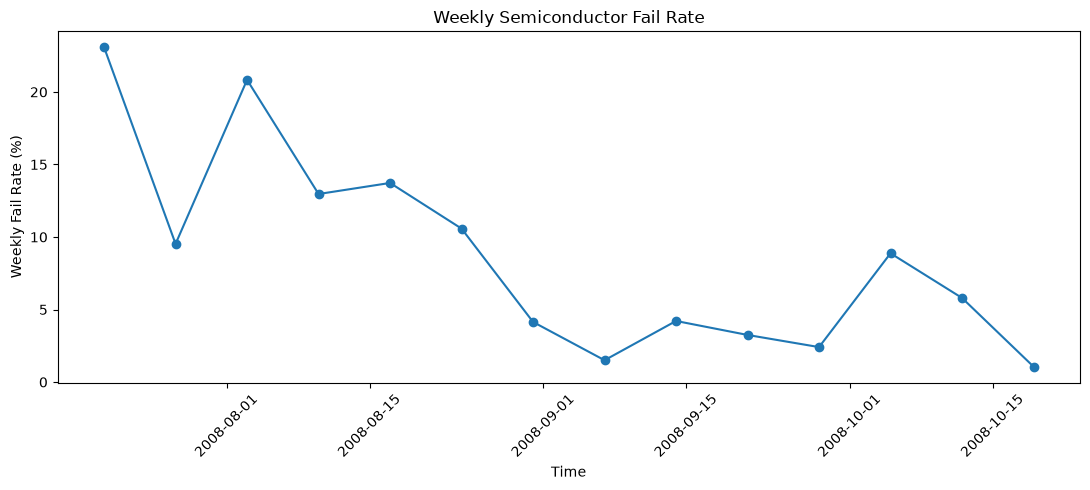

In [30]:
plt.figure(figsize=(11, 5))

plt.plot(
    weekly_fail.index,
    weekly_fail["Fail Rate (%)"],
    marker="o"
)

plt.xlabel("Time")
plt.ylabel("Weekly Fail Rate (%)")
plt.title("Weekly Semiconductor Fail Rate")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

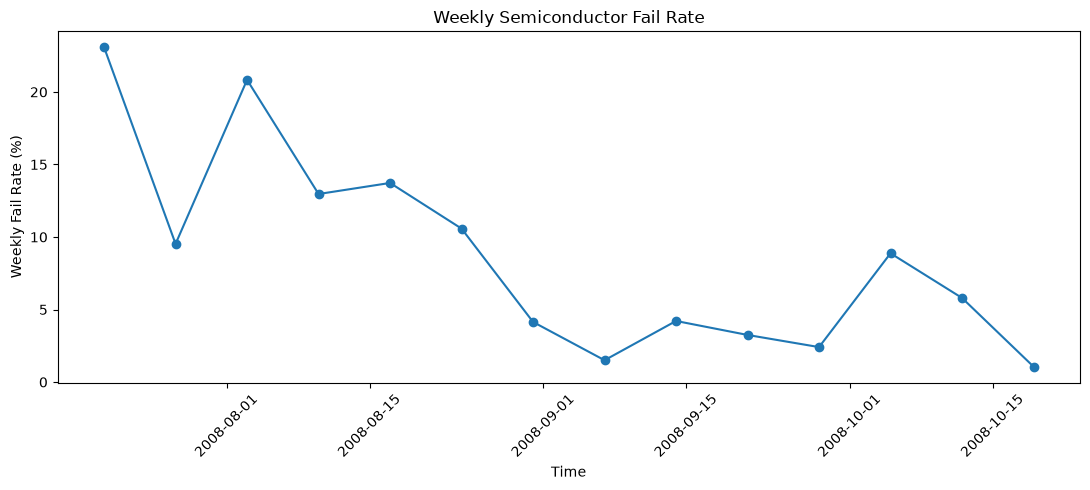

Saved to: ..\results\figures\weekly_fail_rate.png


In [31]:
TIME_FIGURE_PATH = Path(
    "../results/figures/weekly_fail_rate.png"
)

plt.figure(figsize=(11, 5))

plt.plot(
    weekly_fail.index,
    weekly_fail["Fail Rate (%)"],
    marker="o"
)

plt.xlabel("Time")
plt.ylabel("Weekly Fail Rate (%)")
plt.title("Weekly Semiconductor Fail Rate")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    TIME_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved to:", TIME_FIGURE_PATH)

### 시간별 Fail Rate 해석 시 주의사항

주별 Fail Rate의 변화가 관찰되더라도,
특정 기간에 실제 공정 이상이 발생했다고 바로 판단할 수는 없다.

각 기간의 샘플 수가 서로 다를 수 있으며,
SECOM 데이터에는 Lot, Equipment, Chamber, Recipe 등
구체적인 공정 조건을 확인할 수 있는 정보가 제공되지 않는다.

따라서 시간에 따른 Fail Rate 변화는 공정 이상 가능성을 탐색하기 위한
초기 분석 결과로 해석해야 한다.

실제 반도체 제조 환경에서는 시간 정보와 함께 다음과 같은 데이터를
연계하여 추가적인 분석을 수행할 필요가 있다.

- Lot 정보
- Equipment 및 Chamber 정보
- Recipe 및 공정 조건
- Wafer 위치 정보
- 계측(Metrology) 데이터
- Defect 데이터

이러한 정보가 추가될 경우 특정 기간의 불량률 상승과 설비,
공정 조건 및 제품 특성 간의 관계를 보다 구체적으로 분석할 수 있다.

## 6. EDA 종합 결과 (EDA Summary)

SECOM 반도체 제조 데이터를 탐색적으로 분석한 결과,
향후 불량 예측 모델링 과정에서 고려해야 할 주요 데이터 특성을 확인하였다.

### 1. 심각한 클래스 불균형 (Class Imbalance)

전체 1,567개 샘플 중:

- Pass: 1,463개 (약 93.36%)
- Fail: 104개 (약 6.64%)

Fail 샘플의 비율이 매우 낮기 때문에 단순 Accuracy만으로
모델의 실제 불량 검출 성능을 평가하기 어렵다.

따라서 이후 모델 평가에서는 Fail 클래스의 Recall을 중심으로
Precision, F1-score, F2-score, PR-AUC 및 Confusion Matrix를 함께 고려한다.


### 2. 다수의 결측값 (Missing Values)

전체 590개 센서 변수 중 538개 변수에서 하나 이상의 결측값이 확인되었다.

또한:

- 결측률 10% 이상: 52개 변수
- 결측률 20% 이상: 32개 변수
- 결측률 40% 이상: 32개 변수
- 최대 결측률: 약 91.19%

대부분의 센서 변수는 상대적으로 낮은 결측률을 보이지만,
일부 변수에는 매우 높은 비율의 결측값이 집중되어 있다.

따라서 이후 전처리에서는 고결측 변수 제거와
나머지 결측값에 대한 적절한 대체(Imputation)가 필요하다.


### 3. 정보량이 없는 센서 변수 (Non-Informative Features)

일부 센서 변수는 모든 값이 결측되어 있거나,
결측치를 제외한 모든 관측값이 동일하게 나타났다.

이러한 변수는 샘플 간 차이를 구분할 수 없기 때문에
불량 예측에 유용한 정보를 제공하기 어렵다.

따라서 이후 전처리 과정에서 제거 후보로 고려한다.


### 4. 높은 데이터 차원 (High Dimensionality)

SECOM 데이터는 1,567개의 샘플에 대해
590개의 익명 센서 변수를 포함하고 있다.

샘플 수에 비해 변수의 수가 많기 때문에
불필요하거나 중복된 변수가 모델 복잡도를 증가시키고
과적합(Overfitting)을 유발할 가능성이 있다.

따라서 이후 Feature Selection을 통해
예측에 필요한 핵심 변수들을 선별할 필요가 있다.


### 5. Fail과 관련된 센서 패턴

일부 센서 변수는 다른 변수보다 Fail 여부와 상대적으로 높은
통계적 연관성을 보였다.

그러나 가장 높은 상관관계 역시 강한 수준이라고 보기 어렵고,
단일 센서 변수만으로 Pass/Fail을 구분하기에는 한계가 있다.

또한 이러한 결과는 통계적 상관관계일 뿐,
해당 센서 변수가 실제 불량을 발생시키는
Root Cause임을 의미하지 않는다.

SECOM의 센서 변수는 익명화되어 있기 때문에
실제 공정 파라미터와 직접 연결하여 물리적 원인을 판단하는 데에도 한계가 있다.


### 6. 시간에 따른 Fail Rate 변화

시간 단위로 Fail Rate를 집계하여
기간별 불량률 변화 패턴을 탐색할 수 있다.

그러나 각 기간의 샘플 수가 다르고,
Equipment, Chamber, Recipe, Lot 등의 상세 공정 정보가 없기 때문에
특정 기간의 Fail Rate 증가 원인을 직접 판단할 수는 없다.

실제 제조 환경에서는 이러한 공정 메타데이터를 함께 활용하여
설비 및 공정 조건과 불량 발생 간의 관계를 추가적으로 분석할 필요가 있다.


## 다음 단계: 데이터 전처리 (Preprocessing)

EDA를 통해 확인한 데이터 특성을 바탕으로
다음 단계에서는 모델 학습을 위한 데이터 전처리를 수행한다.

주요 방향은 다음과 같다.

1. Training/Test 데이터를 먼저 분리한다.
2. Training Data만을 이용하여 전처리 기준을 결정한다.
3. 모든 값이 결측이거나 정보량이 없는 변수를 제거한다.
4. 높은 결측률을 가진 변수에 대한 제거 기준을 결정한다.
5. 나머지 결측값을 적절한 방법으로 대체(Imputation)한다.
6. 필요한 경우 Feature Scaling 및 Feature Selection을 수행한다.
7. 모든 전처리 과정에서 Data Leakage가 발생하지 않도록 설계한다.